# 05 · Reserve and scarcity

Use the reserve formulation to see what happens when a manual requirement exceeds offered reserve.

**Time:** about 15 minutes. **Package:** PySPD 0.1.0. **Platform tested:** macOS ARM64, Python 3.13.

Run the cells from top to bottom in a fresh kernel. This notebook contains all
its model-building code and uses only the installed package. All data are
fictional; no GDX file, GAMS runtime, repository checkout, or earlier notebook
is needed. Install `pyspd==0.1.0`, `jupyterlab`, `matplotlib`, and `pandas` in
your environment before opening it. SCIP and HiGHS arrive with PySPD.

In [1]:
import sys
from dataclasses import fields, replace
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from IPython.display import display

assert sys.version_info[:2] == (3, 13), "Select a Python 3.13 notebook kernel"
assert version("pyspd") == "0.1.0", "These examples target pyspd==0.1.0"
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.2,
        "figure.dpi": 110,
    }
)
pd.options.display.float_format = "{:,.3f}".format
print({name: version(name) for name in ("pyspd", "highspy", "pyscipopt")})

{'pyspd': '0.1.0', 'highspy': '1.15.1', 'pyscipopt': '5.7.1'}


In [2]:
from pyspd.architecture import ModelAssembler
from pyspd.core_energy import (
    CoreEnergyCase,
)

In [3]:
from pyspd.network import (
    NetworkCase,
    NetworkData,
)

## Define the reserve experiment

The fictional South Island has 80 MW of load and local generation. A manual
requirement is imposed separately for FIR (fast instantaneous reserve) and SIR
(sustained instantaneous reserve). The local generator offers 25 MW of TWRO
(tail-water reserve) in each class at NZD 5/MWh. The named reserve product is
used as a model input category; this is not a representation of a real station.

There is no HVDC link. Both HVDC capacity and control-band limits are zero, so
no reserve can be shared between islands. Reserve scarcity blocks cost NZD
1,000/MWh. These are fictional study parameters, not current market settings.

The input constructors below are longer because the production reserve model
requires explicit energy, network, risk, and sharing domains. Nothing is loaded
from test fixtures or an external file.

In [4]:
def energy_case(demand=80.0, cheap_capacity=60.0, cheap_price=20.0):
    """One fictional island, two offers, one hour, no losses or ramp limits."""
    period = ("DEMO", "H1")
    region = (*period, "NI")
    offers = frozenset((*period, name) for name in ("CHEAP", "LOCAL"))
    blocks = frozenset((*offer, "1") for offer in offers)
    return CoreEnergyCase(
        case_id="DEMO",
        periods=frozenset({period}),
        regions=frozenset({region}),
        offers=offers,
        offer_blocks=blocks,
        primary_offers=offers,
        offer_region={offer: region for offer in offers},
        required_load={region: demand},
        offer_limit={
            block: cheap_capacity if block[2] == "CHEAP" else 120.0 for block in blocks
        },
        offer_price={
            block: cheap_price if block[2] == "CHEAP" else 70.0 for block in blocks
        },
        generation_start={offer: 0.0 for offer in offers},
        ramp_rate_up={offer: 10000.0 for offer in offers},
        ramp_rate_down={offer: 10000.0 for offer in offers},
        interval_minutes={period: 60.0},
        study_mode={period: 130.0},
        movement_penalty=0.0,
    )

In [5]:
def network_case(demand=80.0, line_capacity=100.0, cheap_capacity=120.0):
    """Lossless radial link from the cheap generator to a load and local offer."""
    core = energy_case(demand=demand, cheap_capacity=cheap_capacity)
    p = ("DEMO", "H1")
    nodes = frozenset((*p, name) for name in ("N1", "N2"))
    buses = frozenset((*p, name) for name in ("B1", "B2"))
    line = (*p, "LINE")
    branches = frozenset({line})
    segments = frozenset((*line, "S1", d) for d in ("forward", "backward"))
    data = NetworkData(
        buses=buses,
        branches=branches,
        ac_branches=branches,
        node_bus=frozenset({(*p, "N1", "B1"), (*p, "N2", "B2")}),
        bus_island=frozenset((*bus, "NI") for bus in buses),
        branch_from_bus=frozenset({(*line, "B1")}),
        branch_to_bus=frozenset({(*line, "B2")}),
        branch_bus_connect=frozenset((*line, name) for name in ("B1", "B2")),
        offer_node=frozenset({(*p, "CHEAP", "N1"), (*p, "LOCAL", "N2")}),
        bid_node=frozenset(),
        reference_buses=frozenset({(*p, "B1")}),
        valid_ac_loss_segments=segments,
        branch_constraints=frozenset(),
        market_node_constraints=frozenset(),
        positive_offers=core.offers,
        node_bus_allocation={(*p, "N1", "B1"): 1.0, (*p, "N2", "B2"): 1.0},
        node_load={(*p, "N1"): 0.0, (*p, "N2"): demand},
        bus_electrical_island={bus: 1.0 for bus in buses},
        branch_capacity={(*line, d): line_capacity for d in ("forward", "backward")},
        branch_susceptance={line: 100.0},
        branch_fixed_loss={line: 0.0},
        ac_loss_segment_mw={key: 200.0 for key in segments},
        ac_loss_segment_factor={key: 0.0 for key in segments},
        branch_constraint_sense={},
        branch_constraint_limit={},
        branch_constraint_factor={},
        market_node_constraint_sense={},
        market_node_constraint_limit={},
        market_node_energy_offer_factor={},
        market_node_energy_bid_factor={},
    )
    values = {f.name: getattr(core, f.name) for f in fields(CoreEnergyCase) if f.init}
    values.update(nodes=nodes, node_region={node: (*p, "NI") for node in nodes})
    return NetworkCase(**values, network=data)

In [6]:
def reserve_case(requirement=10.0, offered_reserve=25.0):
    """Two fictional islands, no reserve sharing; a manual SI requirement."""
    from pyspd.hvdc import HvdcData
    from pyspd.reserve import ReserveCase, ReserveData
    from pyspd.reserve.data import (
        BLOCKS,
        ENERGY_BREAKPOINTS,
        RESERVE_BREAKPOINTS,
        RESERVE_CLASSES,
        RESERVE_TYPES,
        RISK_CLASSES,
    )

    base = network_case(demand=80.0)
    p = ("DEMO", "H1")
    islands = frozenset((*p, island) for island in ("NI", "SI"))
    network = replace(
        base.network,
        branches=frozenset(),
        ac_branches=frozenset(),
        branch_from_bus=frozenset(),
        branch_to_bus=frozenset(),
        branch_bus_connect=frozenset(),
        branch_capacity={},
        branch_susceptance={},
        branch_fixed_loss={},
        valid_ac_loss_segments=frozenset(),
        ac_loss_segment_mw={},
        ac_loss_segment_factor={},
        reference_buses=base.network.buses,
        bus_island=frozenset({(*p, "B1", "NI"), (*p, "B2", "SI")}),
        bus_electrical_island={(*p, "B1"): 1.0, (*p, "B2"): 2.0},
    )
    hvdc = HvdcData(
        links=frozenset(),
        sending_bus=frozenset(),
        receiving_bus=frozenset(),
        link_bus=frozenset(),
        breakpoints=frozenset(),
        breakpoint_order={},
        breakpoint_flow={},
        breakpoint_loss={},
        lambda_weight={},
        capacity={},
    )
    risks = {(*i, c, r) for i in islands for c in RESERVE_CLASSES for r in RISK_CLASSES}
    blocks = {
        (*o, b, c, t)
        for o in base.offers
        for b in BLOCKS
        for c in RESERVE_CLASSES
        for t in RESERVE_TYPES
    }
    reserve = ReserveData(
        islands=islands,
        offer_island=frozenset({(*p, "CHEAP", "NI"), (*p, "LOCAL", "SI")}),
        risk_generators=frozenset(),
        primary_secondary_offer=frozenset(),
        risk_group_offer=frozenset(),
        island_risk_group=frozenset(),
        island_link_risk_group=frozenset(),
        directional_risk_factor={},
        reserve_block_limit={
            k: offered_reserve if k[3] == "t1" and k[-1] == "TWRO" else 0.0
            for k in blocks
        },
        reserve_block_price={k: 5.0 for k in blocks},
        reserve_offer_percent={
            (*o, b, c): 1.0
            for o in base.offers
            for b in BLOCKS
            for c in RESERVE_CLASSES
        },
        reserve_generation_maximum={o: 200.0 for o in base.offers},
        reserve_maximum_factor={
            (*o, c): 1.0 for o in base.offers for c in RESERVE_CLASSES
        },
        risk_adjustment_factor={k: 1.0 for k in risks},
        risk_minimum={
            k: requirement if k[2] == "SI" and k[-1] == "manual" else 0.0 for k in risks
        },
        free_reserve={k: 0.0 for k in risks},
        hvdc_pole_ramp_up={k: 0.0 for k in risks},
        secondary_risk_offer={},
        secondary_risk_group={},
        fk_band={o: 0.0 for o in base.offers},
        hvdc_secondary_enabled={},
        hvdc_secondary_subtractor={i: 0.0 for i in islands},
        reserve_share_enabled={(*p, c): 0.0 for c in RESERVE_CLASSES},
        reserve_round_power={(*p, c): 0.0 for c in RESERVE_CLASSES},
        modulation_risk_class={},
        modulation_risk={p: 0.0},
        round_power_zone_exit={(*p, c): 0.0 for c in RESERVE_CLASSES},
        monopole_minimum={p: 0.0},
        hvdc_control_band={(*p, d): 0.0 for d in ("forward", "backward")},
        hvdc_maximum={i: 0.0 for i in islands},
        shared_nfr_maximum={i: 0.0 for i in islands},
        effective_factor={k: 1.0 for k in risks},
        energy_breakpoint_flow={
            (*i, b): float(j * 20)
            for i in islands
            for j, b in enumerate(ENERGY_BREAKPOINTS)
        },
        energy_breakpoint_loss={
            (*i, b): 0.0 for i in islands for b in ENERGY_BREAKPOINTS
        },
        reserve_breakpoint_flow={
            (*i, b): float((j - 6) * 20)
            for i in islands
            for j, b in enumerate(RESERVE_BREAKPOINTS)
        },
        reserve_breakpoint_loss={
            (*i, b): 0.0 for i in islands for b in RESERVE_BREAKPOINTS
        },
        reserve_scarcity_limit={
            (*i, c, b): 100.0 if b == "t1" else 0.0
            for i in islands
            for c in RESERVE_CLASSES
            for b in BLOCKS
        },
        reserve_scarcity_price={
            (*i, c, b): 1000.0 for i in islands for c in RESERVE_CLASSES for b in BLOCKS
        },
        reserve_scarcity_enabled={
            (*i, c): 1.0 for i in islands for c in RESERVE_CLASSES
        },
        market_reserve_offer_factor={},
        market_reserve_bid_factor={},
    )
    values = {f.name: getattr(base, f.name) for f in fields(NetworkCase) if f.init}
    values.update(
        network=network,
        regions=islands,
        offer_region={(*p, "CHEAP"): (*p, "NI"), (*p, "LOCAL"): (*p, "SI")},
        node_region={(*p, "N1"): (*p, "NI"), (*p, "N2"): (*p, "SI")},
        required_load={(*p, "NI"): 0.0, (*p, "SI"): 80.0},
    )
    return ReserveCase(**values, hvdc=hvdc, reserve=reserve)

In [7]:
def solve_reserve(case):
    from pyspd.reserve import (
        ReservePricingEngine,
        ReserveSolvePolicy,
        reserve_formulation,
    )

    built = ModelAssembler().assemble(reserve_formulation(), case)
    outcome = ReserveSolvePolicy().solve(built)
    pricing = ReservePricingEngine().price(built, outcome)
    a = outcome.pricing_model.artifacts
    reserve = sum(
        float(pyo.value(v))
        for k, v in a["reserve"].items()
        if k[2] == "LOCAL" and k[-2] == "FIR"
    )
    return {
        "offered_FIR_mw": reserve,
        "FIR_price": pricing.reserve["DEMO", "H1", "SI", "FIR"],
        "energy_price": pricing.energy.node["DEMO", "H1", "N2"],
        "objective": outcome.pricing_snapshot.objective,
        "FIR_shortfall_mw": sum(
            float(pyo.value(v))
            for k, v in a["reserve_shortfall"].items()
            if k[2] == "SI" and k[3] == "FIR"
        ),
        "shared_reserve_mw": sum(
            float(pyo.value(v)) for v in a["shared_reserve"].values()
        ),
    }

## Solve below and above the offered quantity

`ReserveSolvePolicy` runs native SCIP, fixes the accepted discrete state, then
solves the continuous pricing model with HiGHS. Read quantities and prices
from that accepted pricing model. An optimal solve can still include reserve
shortfall: optimality alone is not a certificate that every requirement was met.

In [8]:
reserve_sweep = pd.DataFrame(
    {"requirement_mw": req, **solve_reserve(reserve_case(req))}
    for req in [5.0, 10.0, 20.0, 30.0, 40.0, 50.0]
)
assert np.allclose(
    reserve_sweep.offered_FIR_mw, np.minimum(reserve_sweep.requirement_mw, 25)
)
assert np.allclose(
    reserve_sweep.FIR_shortfall_mw, np.maximum(reserve_sweep.requirement_mw - 25, 0)
)
assert np.allclose(reserve_sweep.shared_reserve_mw, 0)
assert np.allclose(reserve_sweep.FIR_price, [5, 5, 5, 1000, 1000, 1000])
display(reserve_sweep.drop(columns="objective"))

,requirement_mw,offered_FIR_mw,FIR_price,energy_price,FIR_shortfall_mw,shared_reserve_mw
0,5.000,5.000,5.000,70.000,0.000,0.000
1,10.000,10.000,5.000,70.000,0.000,0.000
2,20.000,20.000,5.000,70.000,0.000,0.000
3,30.000,25.000,"1,000.000",70.000,5.000,0.000
4,40.000,25.000,"1,000.000",70.000,15.000,0.000
5,50.000,25.000,"1,000.000",70.000,25.000,0.000


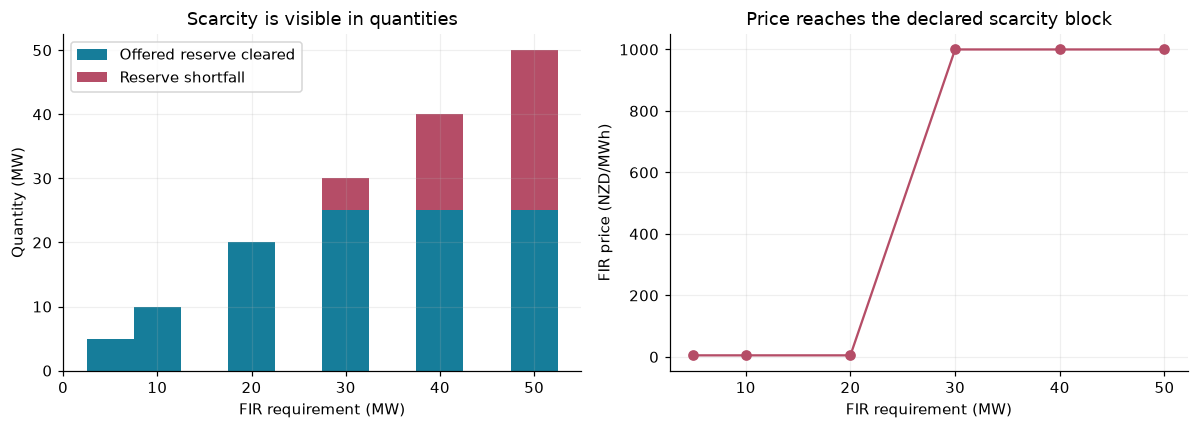

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = reserve_sweep.requirement_mw
axes[0].bar(
    x,
    reserve_sweep.offered_FIR_mw,
    width=5,
    label="Offered reserve cleared",
    color="#167d9a",
)
axes[0].bar(
    x,
    reserve_sweep.FIR_shortfall_mw,
    bottom=reserve_sweep.offered_FIR_mw,
    width=5,
    label="Reserve shortfall",
    color="#b54d67",
)
axes[0].set(
    xlabel="FIR requirement (MW)",
    ylabel="Quantity (MW)",
    title="Scarcity is visible in quantities",
)
axes[0].legend()
axes[1].plot(x, reserve_sweep.FIR_price, "o-", color="#b54d67")
axes[1].set(
    xlabel="FIR requirement (MW)",
    ylabel="FIR price (NZD/MWh)",
    title="Price reaches the declared scarcity block",
)
fig.tight_layout()
display(fig)
plt.close(fig)

## Try it

Raise `offered_reserve` to 40 MW and rerun the sweep. The scarcity boundary
should move. Do not assert a unique price at exactly the reserve-offer limit;
left and right sensitivities differ there. Energy and reserve are modeled
together, but the plant's declared 200 MW generation-plus-reserve maximum is
deliberately nonbinding in this experiment.